In [24]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="20" color="red">ch12.데이터시각화</font>
- 시각화 라이브러리 : matplotlib,seaborn,folium(지도시각화)                                 
                                       
- maplotlip : 파이썬에서 가장 기본적으로 사용하는 시각화 라이브러리. 판다스 내부에 포함
- seaborn : matplotlip 기반으로 다양한 색, 테마, 차트 기능과 groupby기능을 추가한 라이브러리

# 1절. matplotlip
- api 참조 url : https://matplotlib.org/stable/api/index.html

## 1.1 패키지 import 및 기본 설정

In [2]:
import matplotlib
matplotlib.__version__

'3.7.0'

%matplotlib inline : 주피터 노트북에서 실행되는 브라우저에서 시각화로 바로하도록

In [85]:
import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
# 한글설정(win/MacOS)

# warning(경고) 안보이게
import warnings
warnings.filterwarnings(action='ignore') # 경고 메시지 안보이게
warnings.filterwarnings(action='default') # 경고 메시지 다 보이게
import seaborn as sns

## 1.2 그래프 그리기
- matplotlib으로 그래프를 그리기 위한 단계
    1) 데이터 준비
    2) 그래프 생성
    3) 그래프 함수로 그리기
    4) 그래프 커스터마이징
    5) 그래프 출력 및 저장

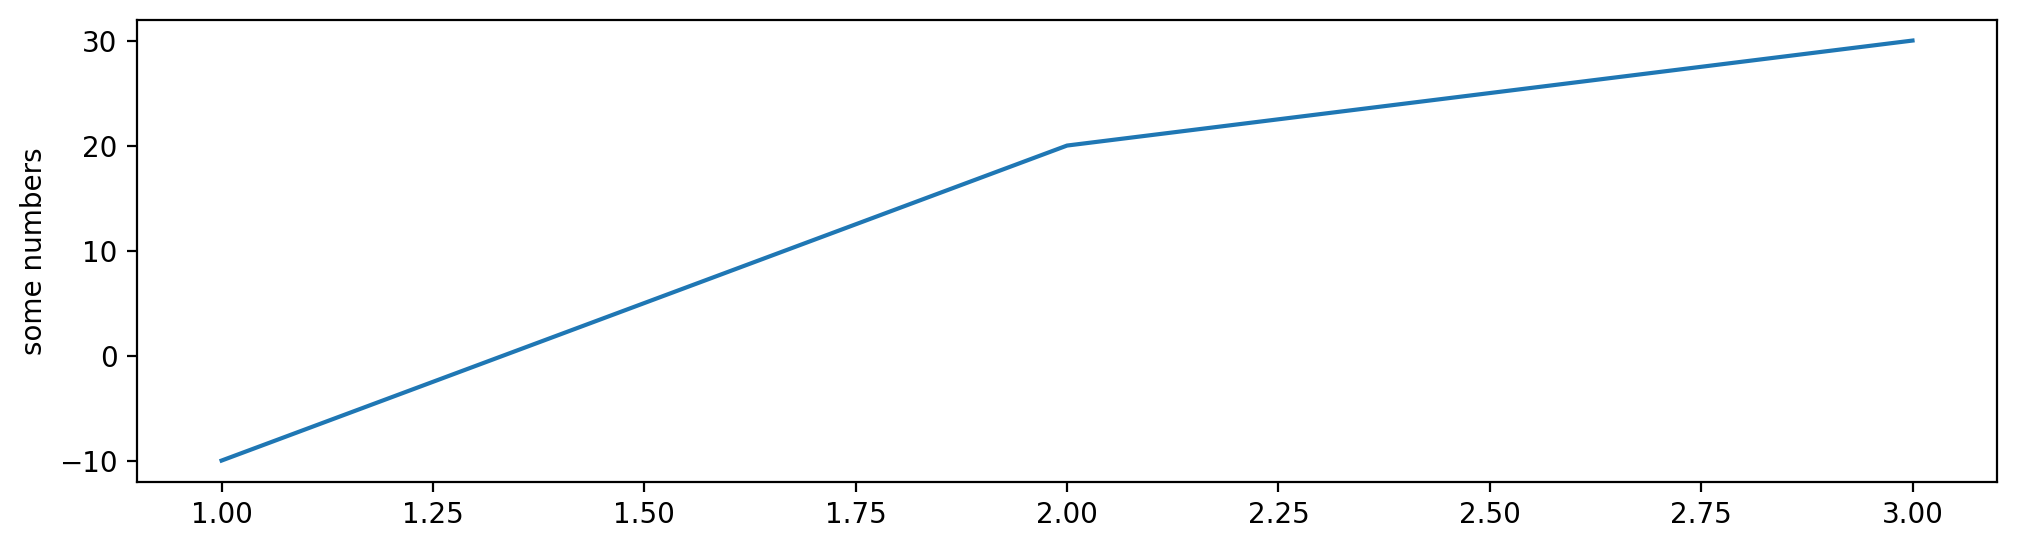

In [10]:
x = [1,2,3] #데이터 준비
y = [-10,20,30]
plt.figure(figsize=(12,3)) # 2)원하는 사이즈의 그래프 객체 생성
plt.plot(x,y) #3) 그래프 함수로 그리기
plt.ylabel('some numbers') # 4)커스터마이즈
plt.savefig('data/ch12_plot.png',bbox_inches='tight',dpi=300)# 5) 그래프 저장
plt.show() # 6) 그래프 저장

## 1.3 그래프 영역 나누기
### 1) subplot() 함수로 서브플롯 추가

In [46]:
import numpy as np
x = np.linspace(0,9.9,10)
x.shape

(10,)

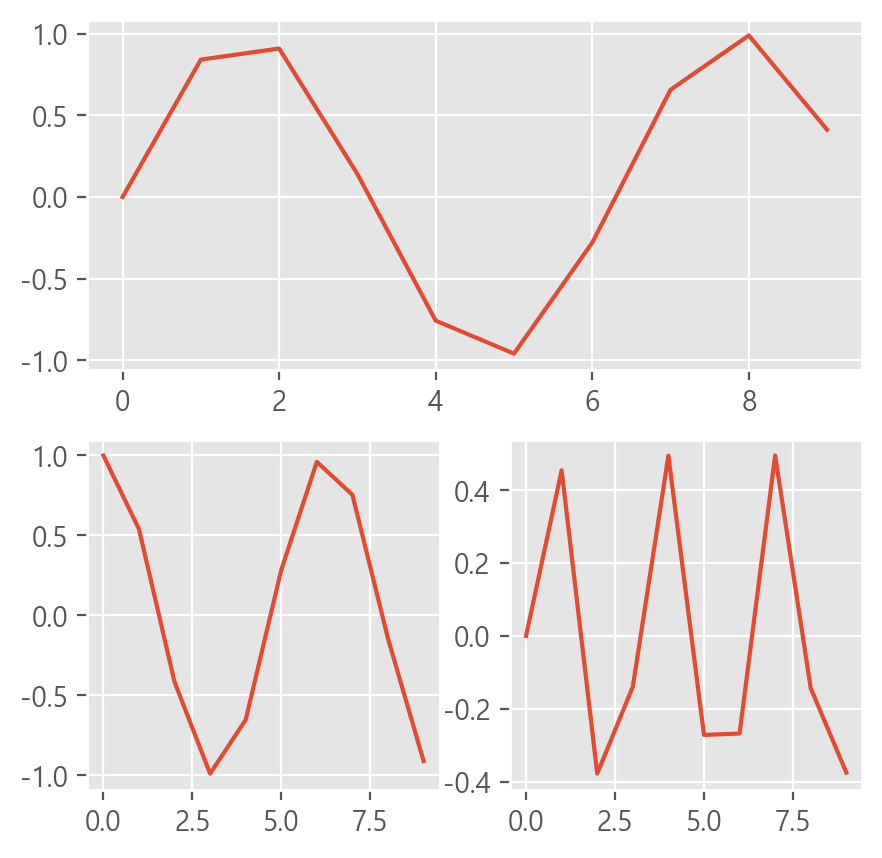

In [192]:
# plt.figure(figsize=(5,5)) #그래프 사이즈가 이번셀만 
plt.rcParams['figure.figsize']=(5,5) # 그래프 사이즈 셋팅(다음셀도 적용)
plt.subplot(2,1,1) #2행1열의 subplot에서 1번째 subplot을 다음과 같이 그린다.
plt.plot(x,np.sin(x))
plt.subplot(2,2,3) #2행 2열의 subplot에서 3번째 subplot을 다음과 같이 그린다.
plt.plot(x,np.cos(x))
# plt.subplot(2,2,4)
plt.subplot(224)
plt.plot(x,np.sin(x)*np.cos(x))
plt.show()

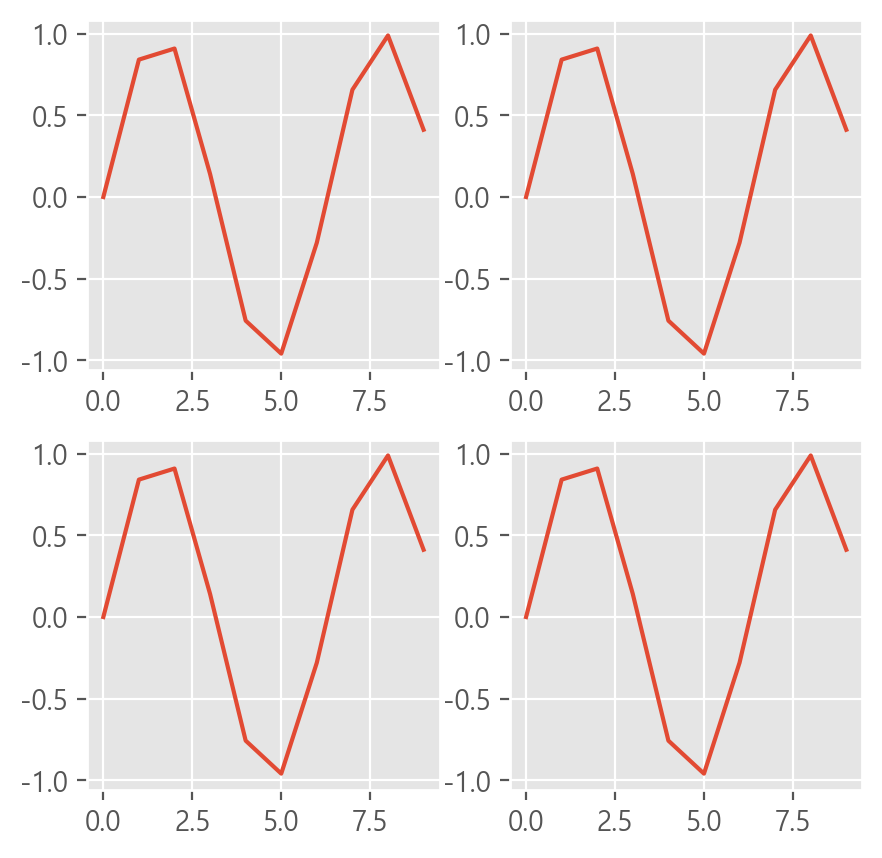

In [193]:
plt.subplot(221);plt.plot(x,np.sin(x))# 2행2열 1번째 plot
plt.subplot(222);plt.plot(x,np.sin(x))# 2행2열 2번째 plot
plt.subplot(2,2,3);plt.plot(x,np.sin(x))
plt.subplot(2,2,4);plt.plot(x,np.sin(x))
plt.show()

### 2) subplots() 함수로 서브플롯 생성
- plot함수에서 색상이나 스타일을 조정 : https://wikidocs.net/92085

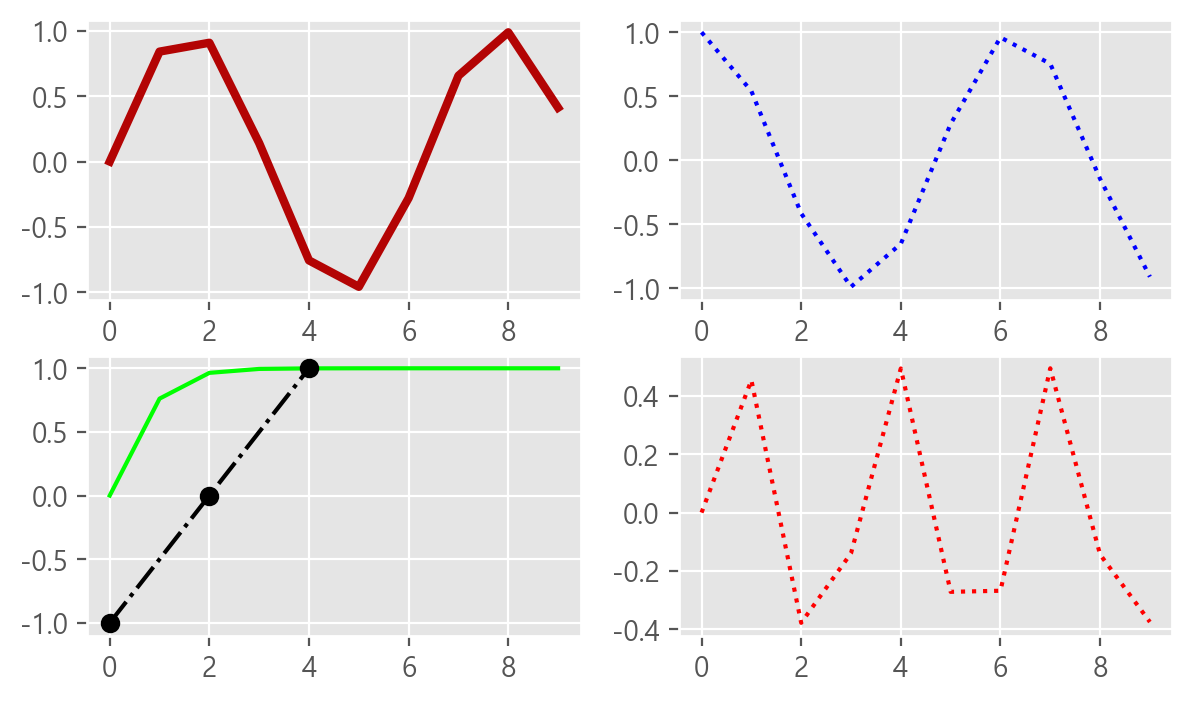

In [194]:
fig,axes=plt.subplots(nrows=2,ncols=2, figsize=(7,4))
axes[0,0].plot(x,np.sin(x),c='#b30404',lw=3) #color ='r',linewidth=3
axes[0,1].plot(x,np.cos(x),'b:')#color ='b',linewidth='--'(대시라인), : (점선)
axes[1,0].plot(x,np.tanh(x),'#00FF00') # c='#00FF00'
axes[1,0].plot([0,2,4],[-1,0,1],'ko-.')# c='k',marker='o',linewidth='-.'
axes[1,1].plot(x,np.sin(x)*np.cos(x),'r:')
plt.show()

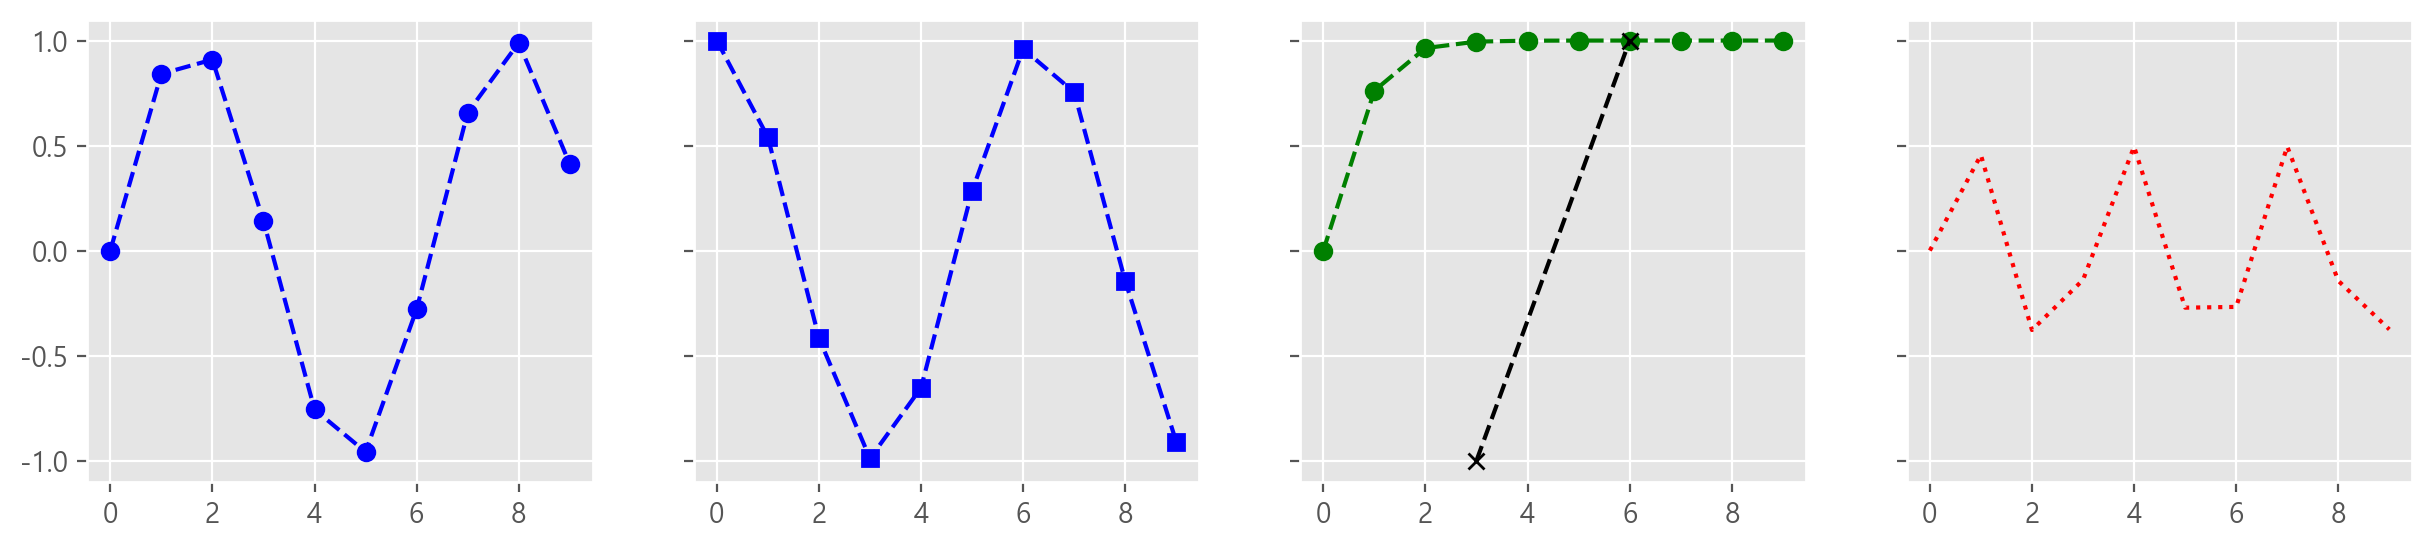

In [195]:
# 1행 4열 서브플롯(for문)
func_list=[np.sin,np.cos,np.tanh,lambda x:np.sin(x)*np.cos(x)]
fmt_list = ['bo--','bs--','go--','r:']
fig,axes = plt.subplots(1,4,figsize=(15,3),sharey=True)# y축 공유
for i,ax in enumerate(axes):
    ax.plot(x,func_list[i](x), fmt_list[i])
axes[2].plot([3,6],[-1,1],'kx--')

## 1.4 다양한 그래프 그리기
### 1)pyplot 함수들(교안 16)
- https://matplotlib.org/api/_as_gen/matplotlib.pyplot.html
### 2)matplotlib.pyplot.plot() : 선그래프

In [ ]:
# c, color(칼라) :  https://wikidocs.net/92085
# marker = o,^,x,s
# linestyle = -(실선), --(대시라인), :(점선),-.

### 3)pandas.DataFrame.plot()
- plt.plot(x,y,fmt)
- df.plot(x=None, y=None, kind='line'
    * kind : line(기본값),scatter(점도표),bar(막대),barh(가로막대),box,density=kde밀도추정,hist(빈도)...
    * figsize : tuple(인치단위)
    * xlim,ylim(축의범위) : list/tuple
    

In [61]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.sample(2)

,sepal_length,sepal_width,petal_length,petal_width,species
76,6.8,2.8,4.8,1.4,versicolor
146,6.3,2.5,5.0,1.9,virginica


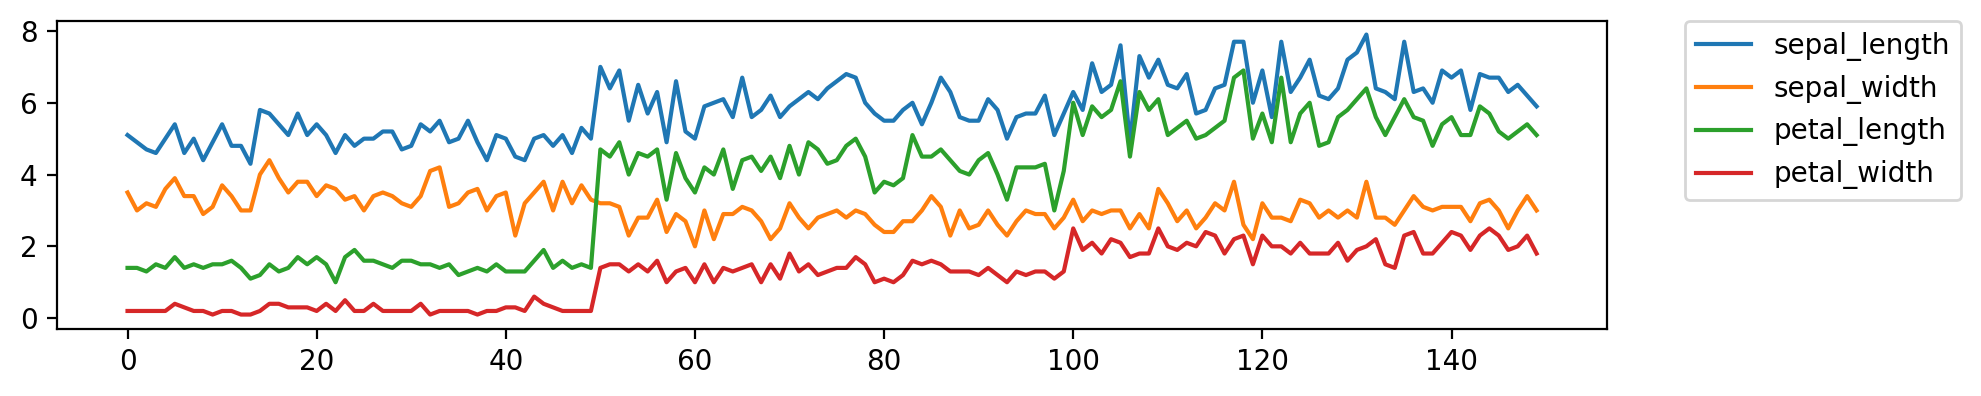

In [65]:
#
plt.rcParams['figure.figsize']=(10,2)
plt.plot(iris.index,iris.iloc[:,:-1])
# plt.legend(iris.columns[:-1])
plt.legend(iris.columns[:-1],bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

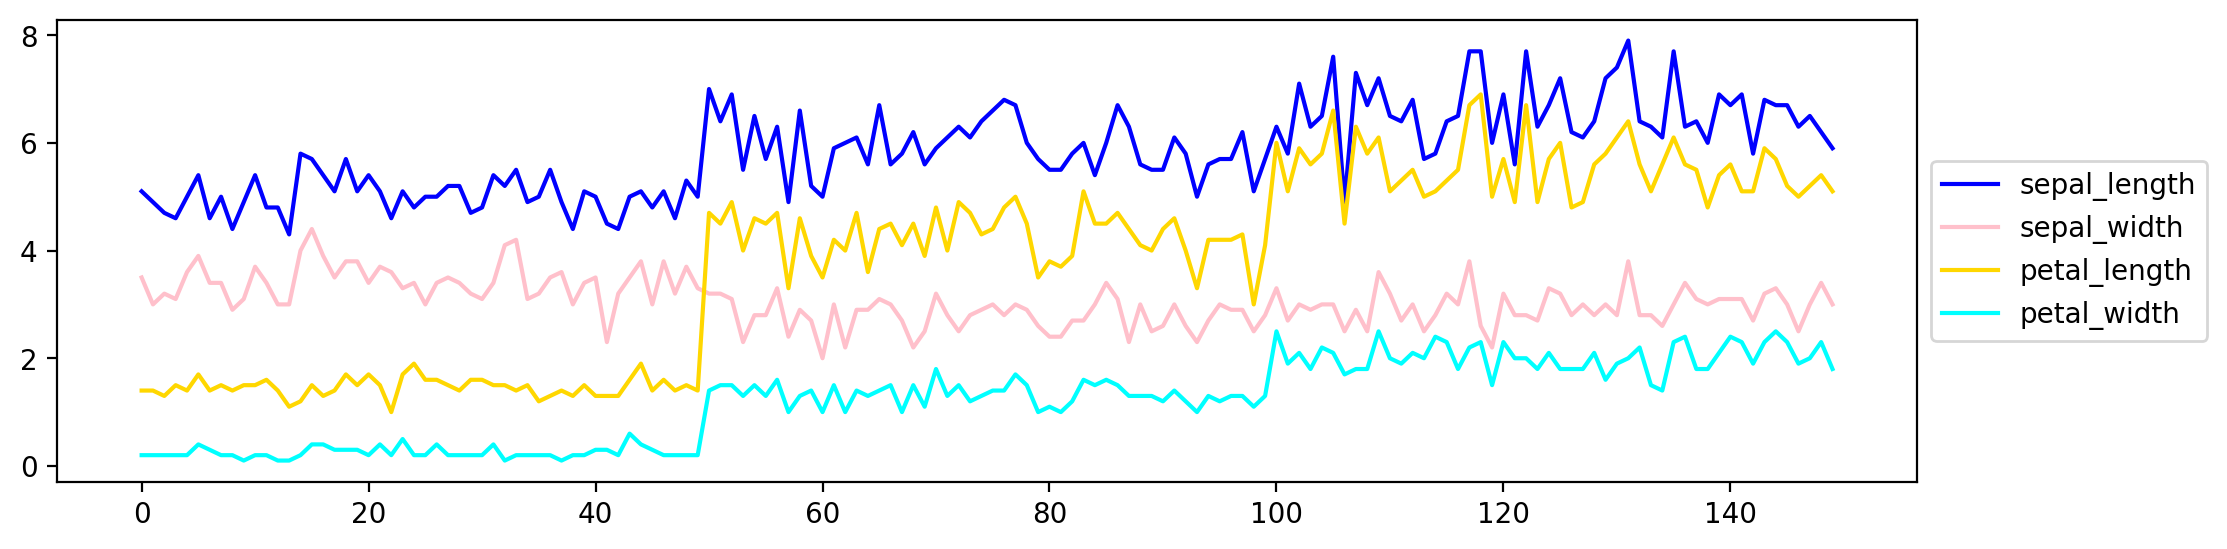

In [74]:
g=iris.plot(kind='line',# 그래프 종류
        figsize=(12,3), # 크기
        color=['blue','pink','gold','aqua'],#그래프 색상
        )
g.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

- 교안(21p)

    *https://ko.wikipedia.org/wiki/상자 수염 그림
    
    *https://matplotlib.org/stable/tutorials/colors/colormaps.html colormap

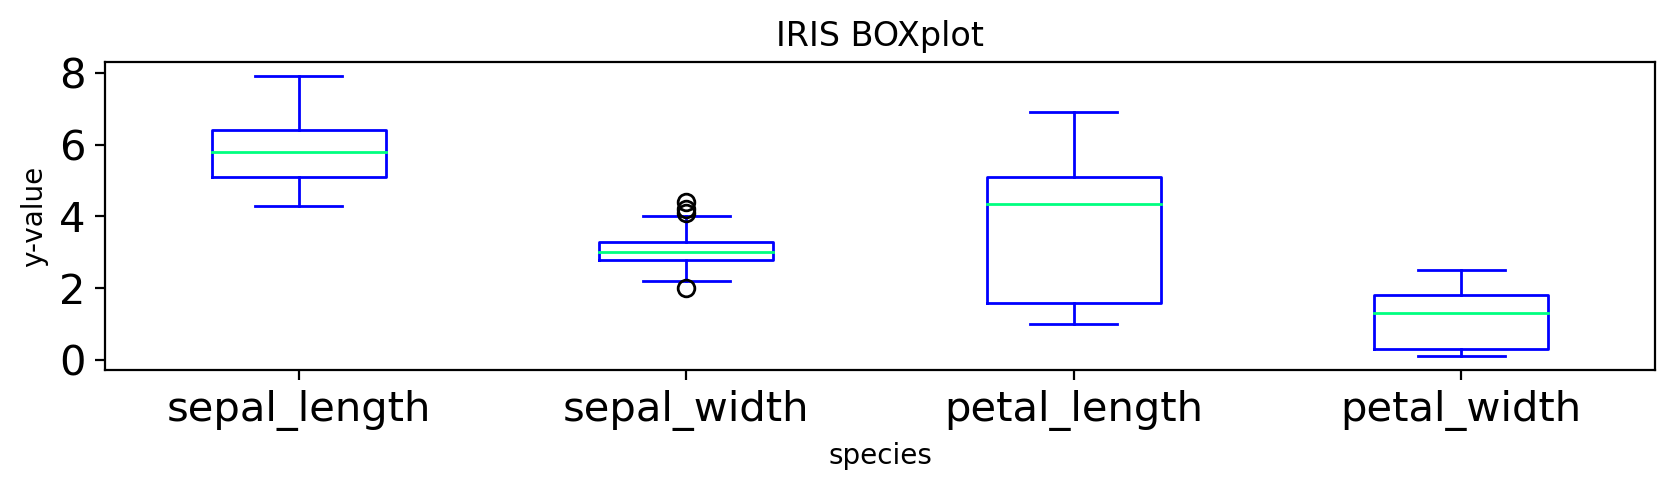

In [81]:
iris.plot(kind='box',
         colormap='winter',
         title='IRIS BOXplot',
         ylabel='y-value',
         xlabel='species',
         fontsize=15)
plt.show()

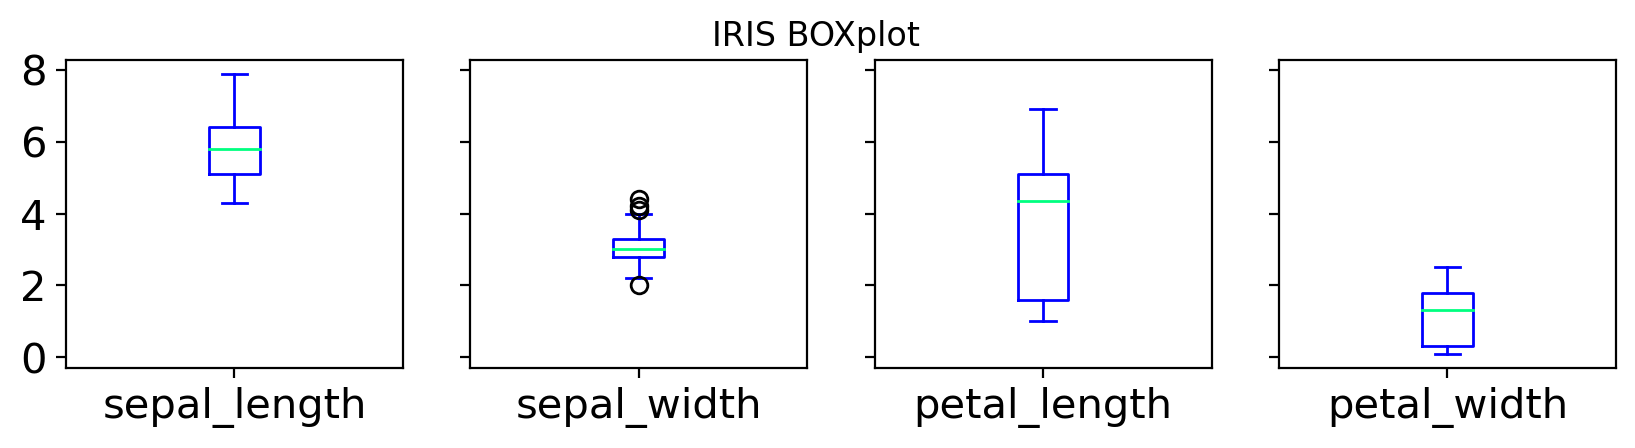

In [83]:
iris.plot(kind='box',
         colormap='winter',
         title='IRIS BOXplot',
         subplots=True,
         sharey=True,   
         fontsize=15)
plt.show()

In [87]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


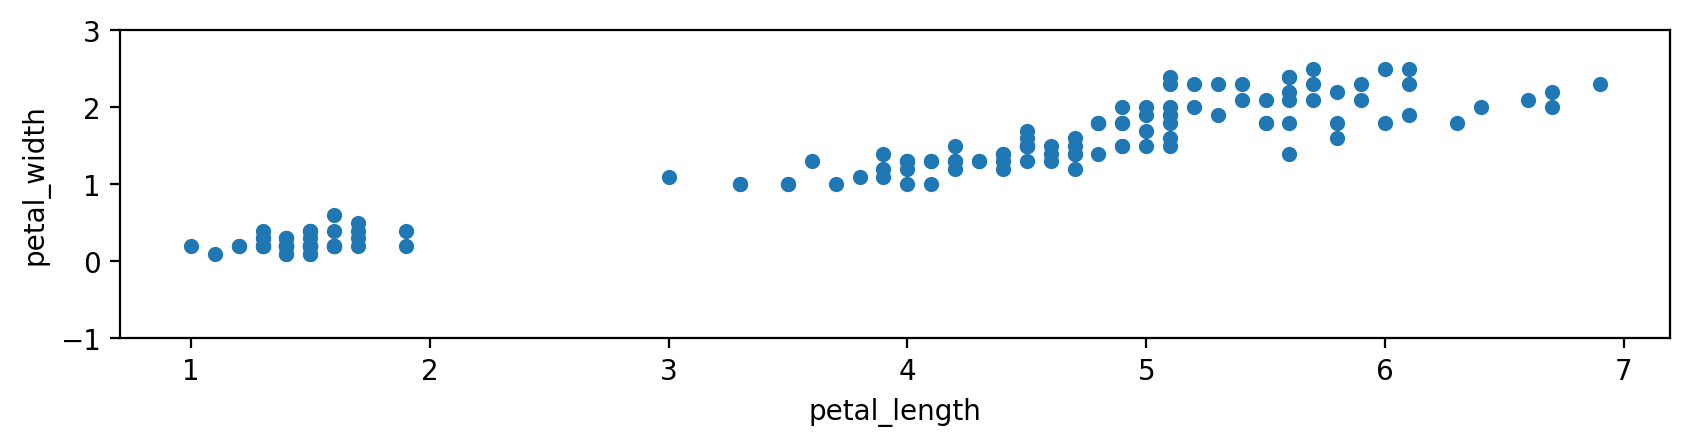

In [89]:
iris.plot(kind='scatter',x='petal_length',y='petal_width',ylim=[-1,3])#y축 범위 조정
plt.show()

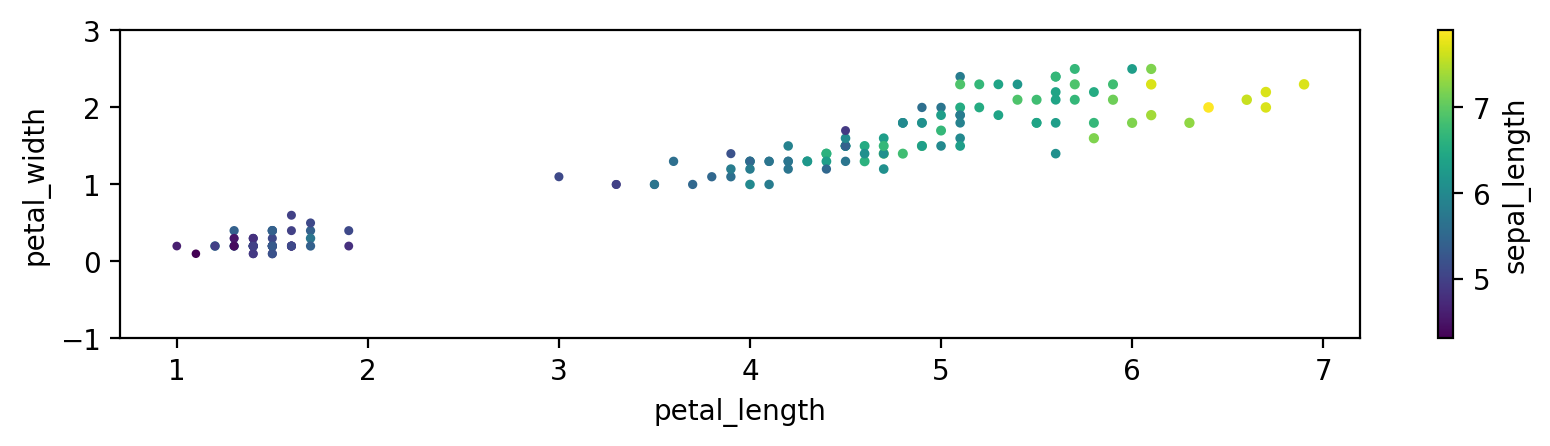

In [90]:
iris.plot(kind='scatter',x='petal_length',y='petal_width',
          s='sepal_length', #점의 크기
          c='sepal_length', #점의 색상
          ylim=[-1,3])#y축 범위 조정
plt.show()

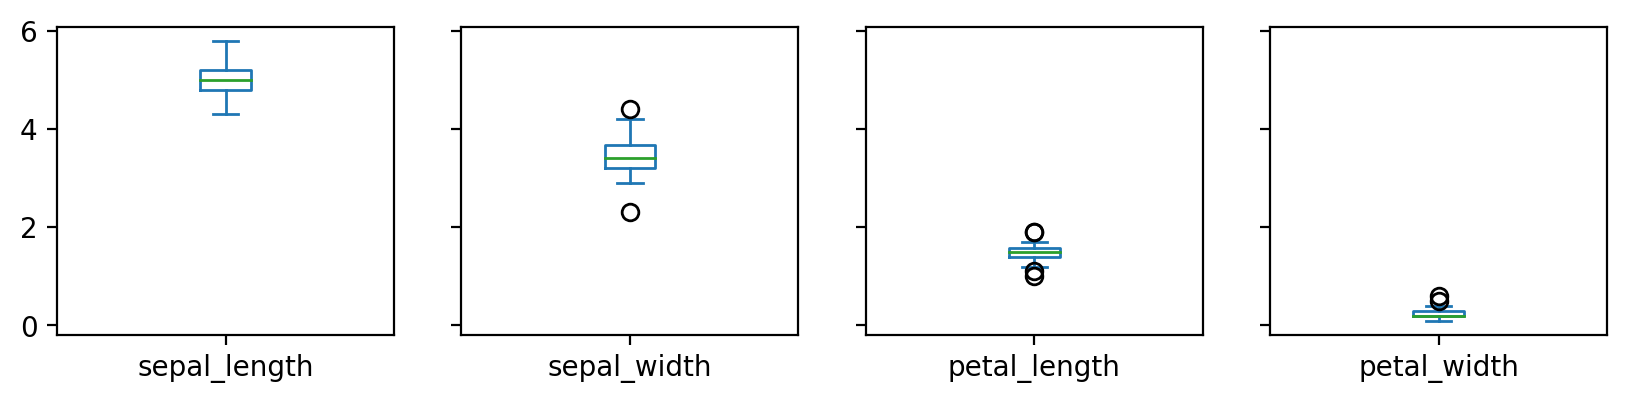

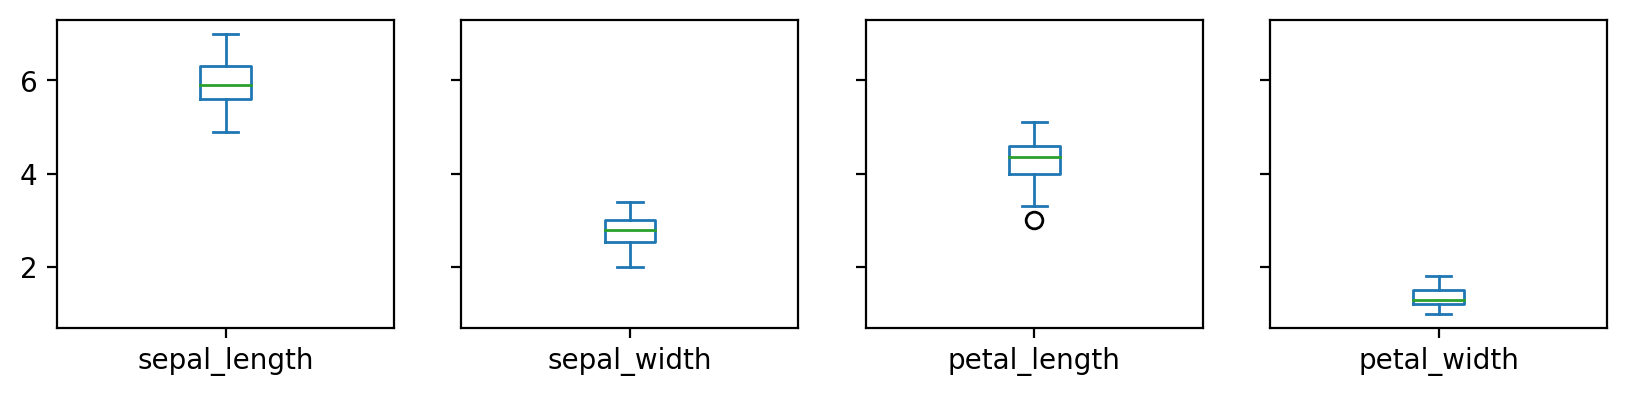

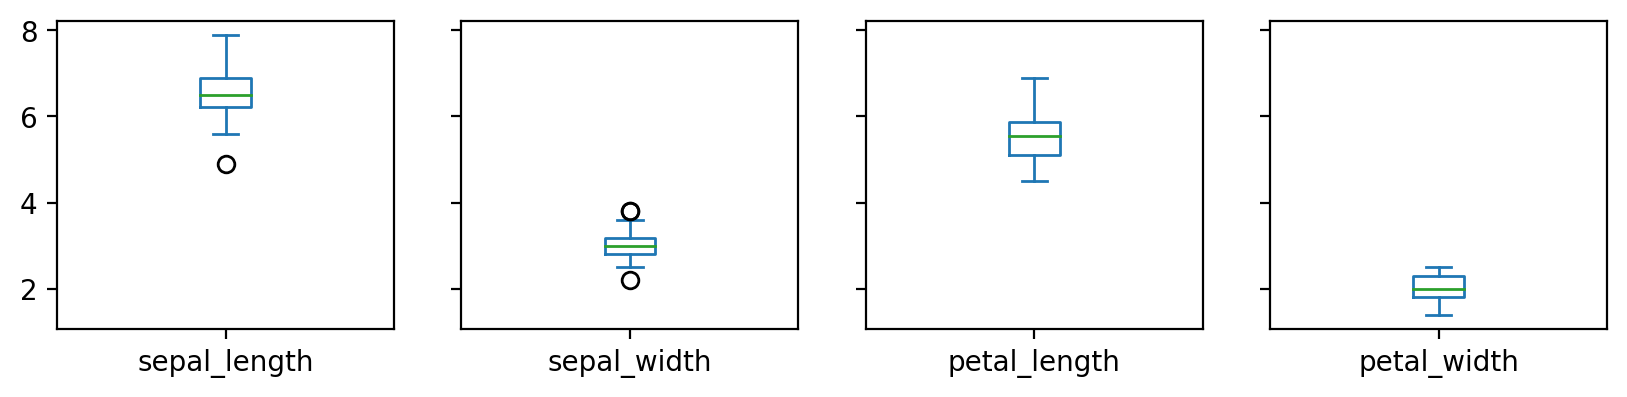

In [94]:
# 종별 boxplot
iris.groupby('species').plot(kind='box',
                                  subplots=True,
                                  sharey=True,
#                                   layout=(3,4)
                                  )
plt.show()

### 4)plt.scatter() : 산점도
- x,y 축이 수치형

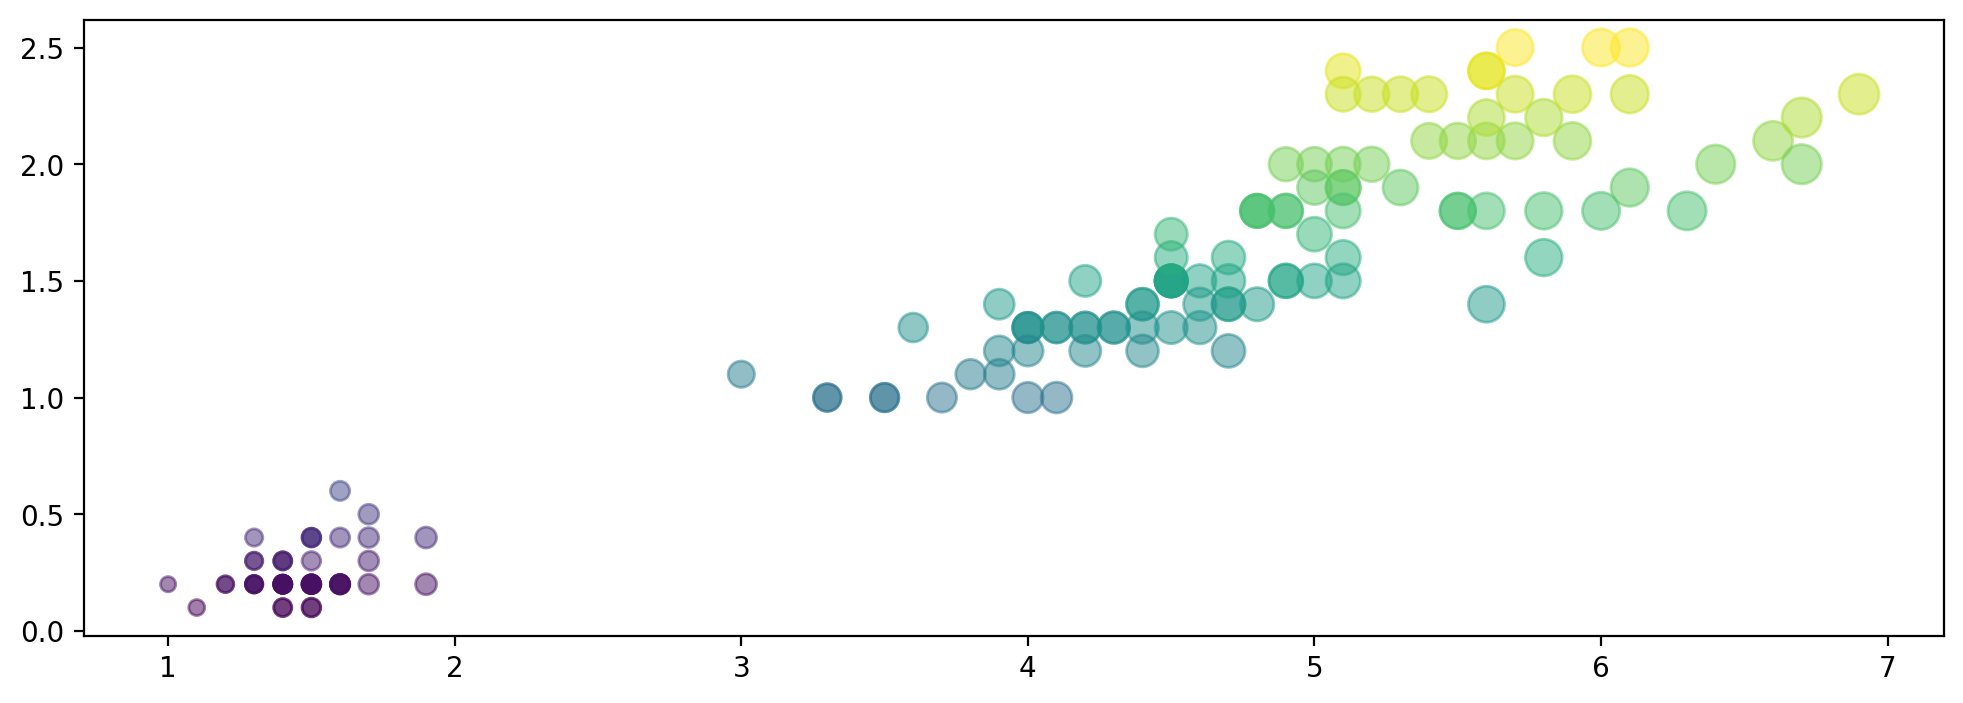

In [97]:
#plt.rcParams['figure.figsize'] = (10,2)
plt.figure(figsize=(12,4))
plt.scatter(iris.petal_length,iris.petal_width,
           s=iris.petal_length*30, #점크기
           c=iris.petal_width*20,
           alpha=.5) # 투명도(투명0,불투명1)
plt.show()

In [ ]:
# plt.rcParams['figure.figsize'] = (10,2)
plt.figure(figsize=(12,4))

## 1.5 그외 그래프 그리기
### 1)boxplot(분포를 모름), violinplot(분포보여줌)

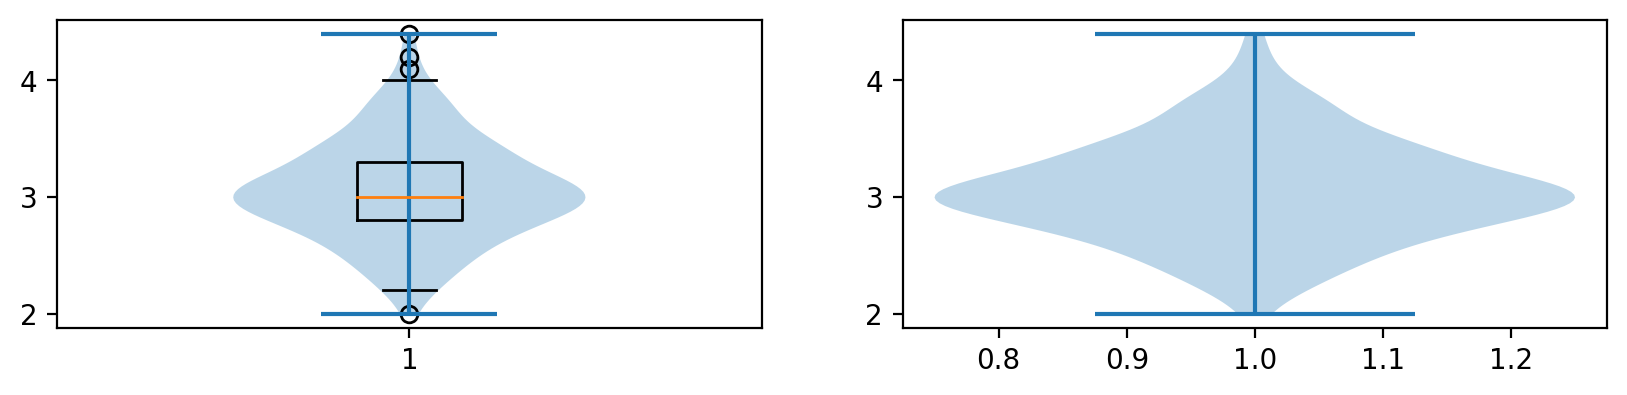

In [107]:
fig, axes = plt.subplots(ncols=2)
axes[0].boxplot(iris.sepal_width)
axes[0].violinplot(iris.sepal_width)
axes[1].violinplot(iris.sepal_width)
# sns.violinplot(y=iris.sepal_length,ax=axes[1])
plt.show()

### 2)bar(),barh()

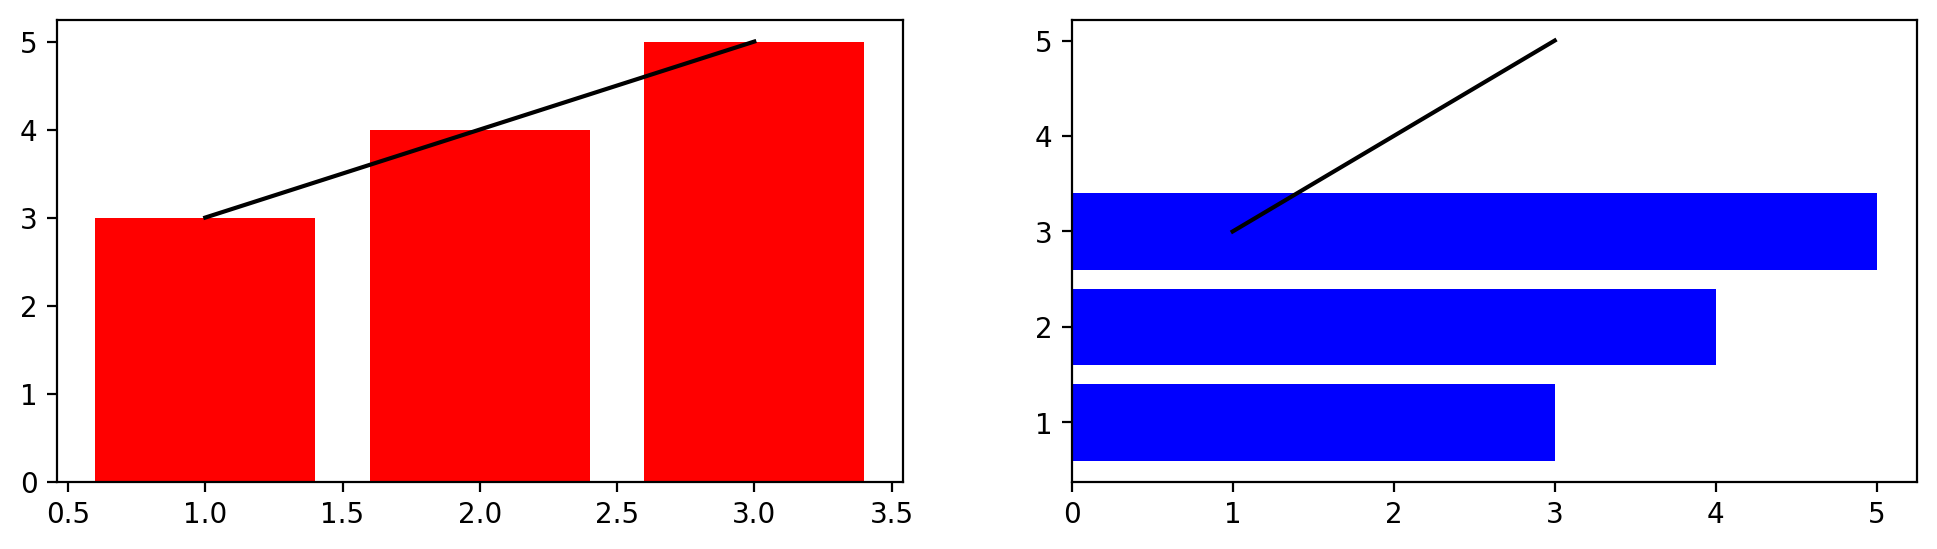

In [111]:
x=[1,2,3]
y=[3,4,5]
fig, axes = plt.subplots(ncols=2,figsize=(12,3))
axes[0].bar(x,y,color='r')
axes[0].plot(x,y,c='k')
axes[1].barh(x,y,color='b') # 가로 막대 그래프는 x와 y가 바뀐다.
axes[1].plot(x,y,'k')

### 3)hist(히스토 그램.도수분포표를 그래프화)

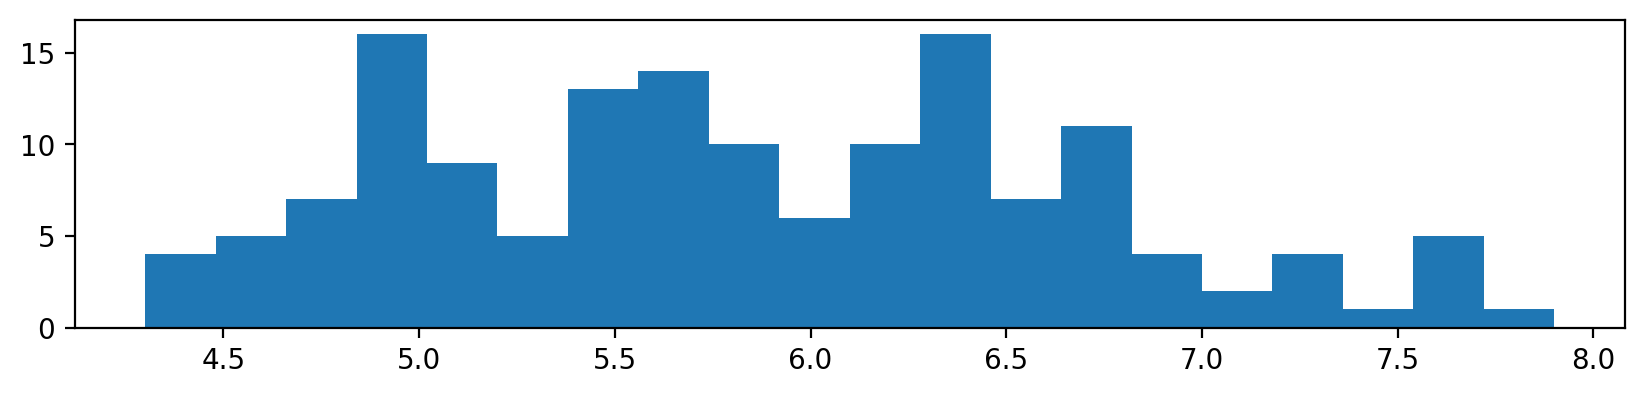

In [118]:
# plt.hist(iris.sepal_length,bins=20, orientation='horizontal')# 가로 histogram
# plt.hist(iris.sepal_length, bins=20, cumulative=True) # 누적 histogram
plt.hist(iris.sepal_length,bins=20)
plt.show()

### 4)axvline(),axhline(),fill(),fill_between()

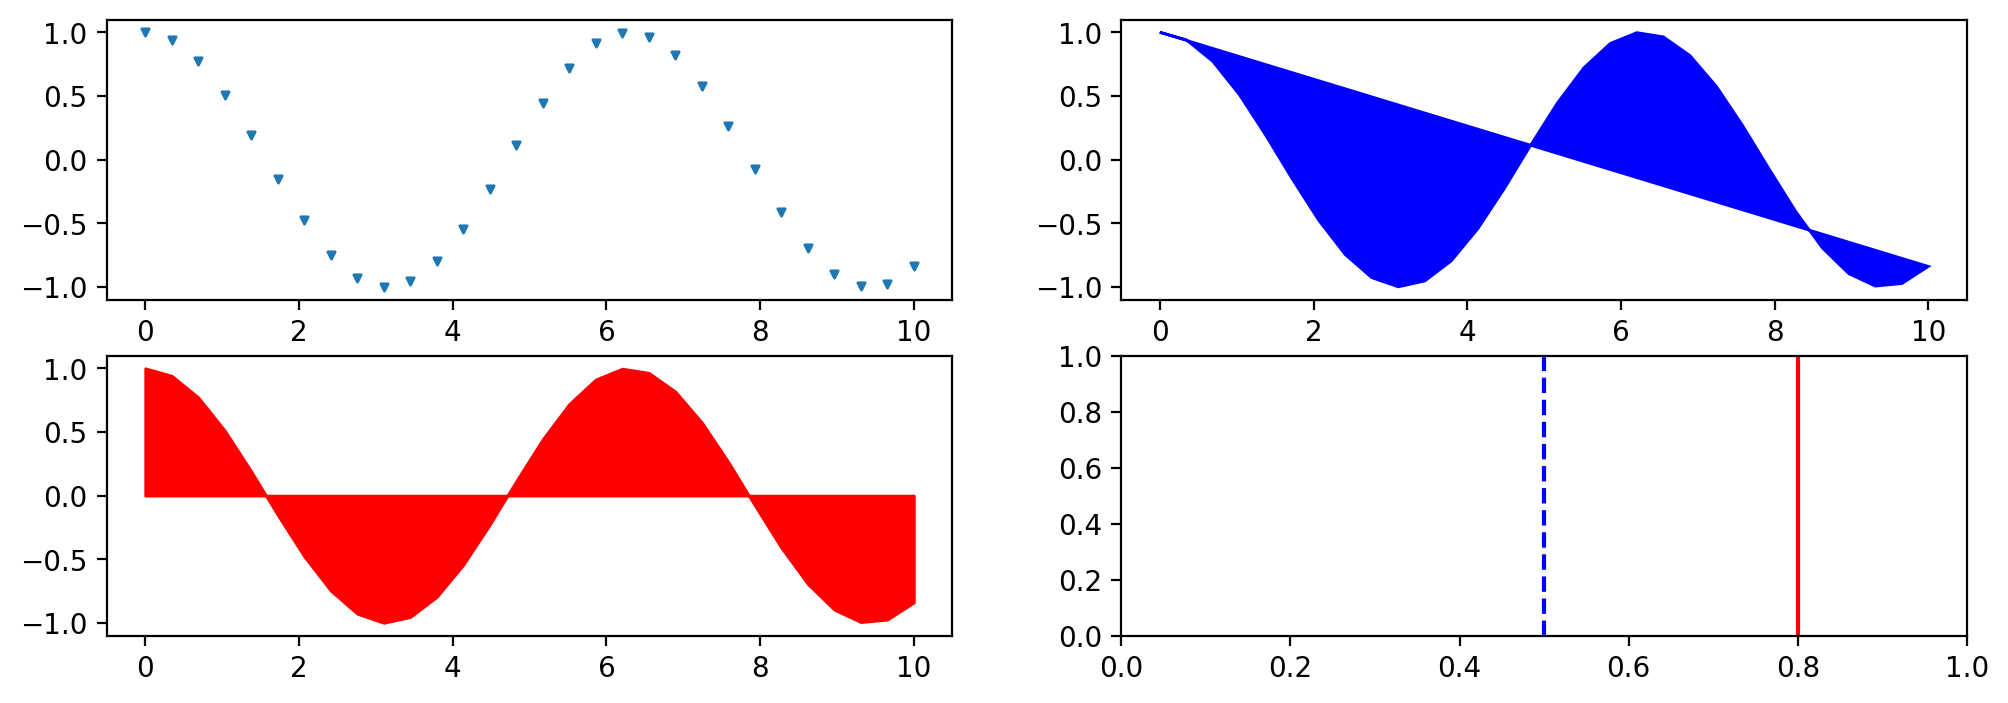

In [129]:
x = np.linspace(0,10,30) # 기본값은 50개 데이터 생성
y = np.cos(x)
fig, axes = plt.subplots(2,2,figsize=(12,4))
axes[0,0].scatter(x,y,s=7,marker='v')
axes[0,1].fill(x,y,c='b')
axes[1,0].fill_between(x,y,color='r')
axes[1,1].axvline(0.5,c='b',linestyle='--')
axes[1,1].axvline(0.8,c='r')

### 5)pie

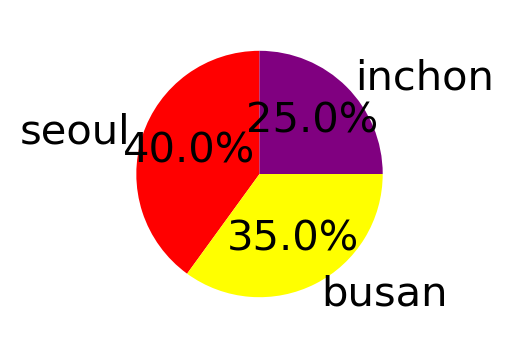

In [135]:
cnt = [40,35,25]
labels = ['seoul','busan','inchon']
colors = ['red','yellow','purple']
plt.pie(cnt,startangle=90,
       autopct="%.1f%%",        
       textprops={'fontsize':15},
       labels=labels,
       colors=colors)
plt.show()

## 1.6 그래프 커스터마이징
### 1) linestyle,linewidth,color,marker...
### 2) text(),annotate()
- 교안 29p 참고: https://matplotlib.org/api/axes_api.html#text and annotations

In [150]:
# 한글 폰트 설정하는 방법1
plt.style.use('ggplot')#default
plt.rc('font',family='Malgun Gothic')#윈도우즈
# plt.re('font',family='AppleGothic')#MacOS
plt.rc('axes',unicode_minus=False)

In [153]:
# 한글 특정폰트 설정하는 방법2
from matplotlib.font_manager import FontProperties
font_path = r'C:\Windows\Fonts\MalangmalangR.ttf'
#폰트 다운로드 : 네이버,구글,눈누,산들 등에서  *.TTF파일 다운
font_prop = FontProperties(fname=font_path, size=10)

In [ ]:
# 한글 특정폰트 설정하는 방법3
# pip install koreanize-matplotlib 한줄이면 보통 NanumGothic으로 세팅

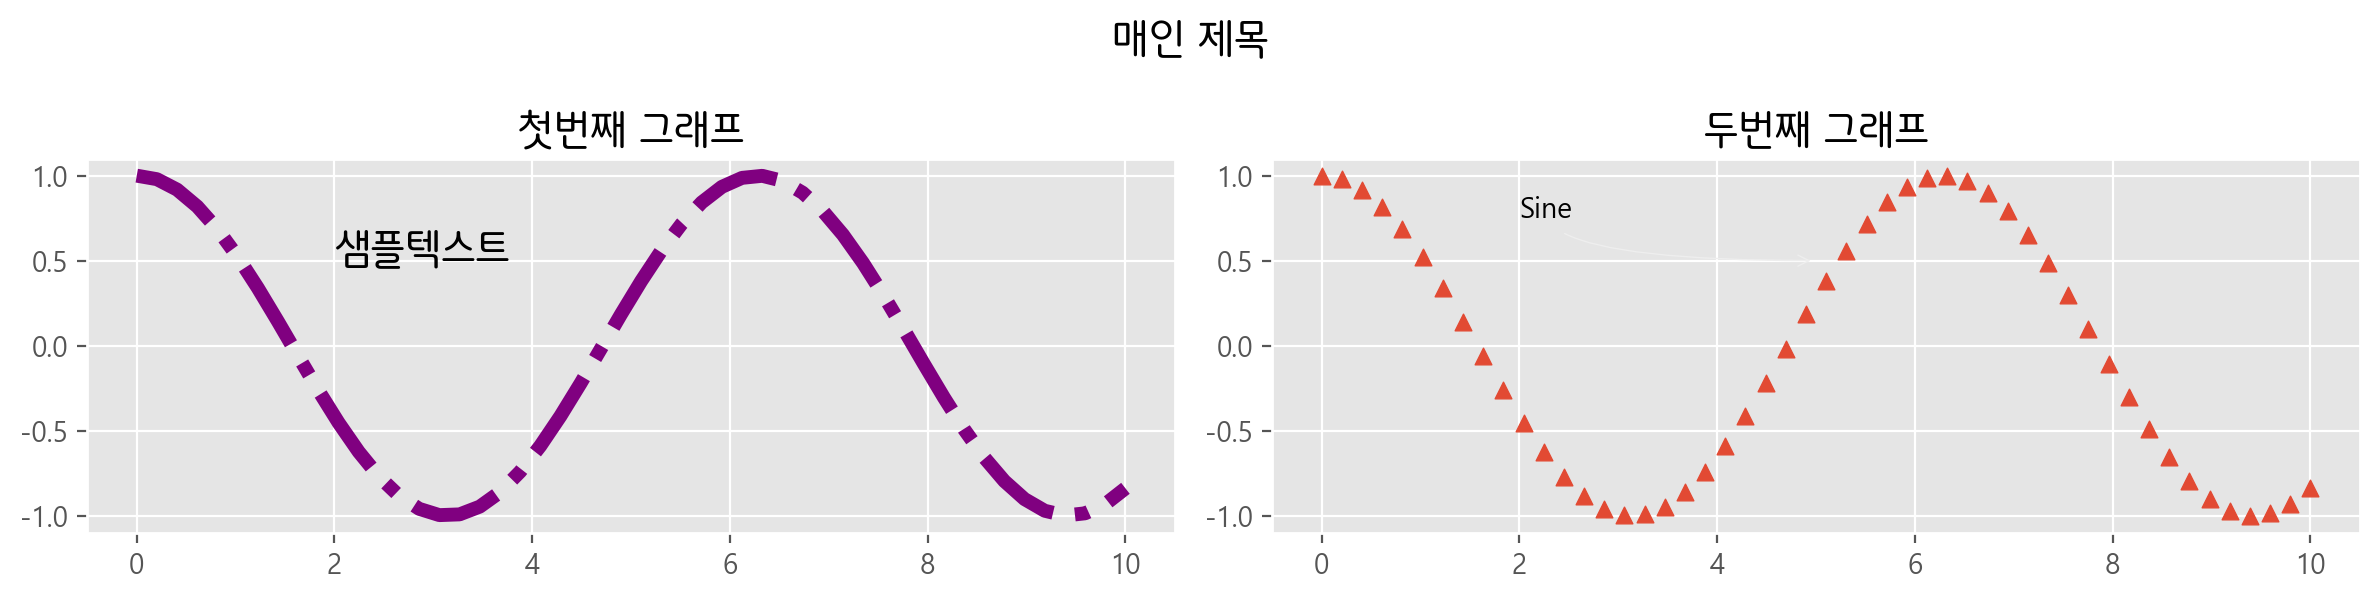

In [163]:
x = np.linspace(0,10)
y = np.cos(x)
fig,axes = plt.subplots(1,2,figsize=(12,3))
axes[0].plot(x,y,linewidth=5,linestyle='-.',color='purple') # lw=5,ls='-.',c='purple'
#텍스트 추가
axes[0].text(2,0.5, # 텍스트가 위치할곳의 좌표
            '샘플텍스트',
            font_properties=font_prop,fontsize=15)
axes[0].set_title('첫번째 그래프',font_properties=font_prop,fontsize=15)
#annotate추가
axes[1].scatter(x,y,marker='^')
axes[1].annotate('Sine',xytext=(2,0.75),
                xy=(5,0.5),
                arrowprops=dict(arrowstyle='->',
                                connectionstyle='angle3'))
axes[1].set_title('두번째 그래프',font_properties=font_prop,fontsize=15)
plt.suptitle('매인 제목',font_properties=font_prop,fontsize=15)
plt.tight_layout()
plt.show()

### 3)수학기호
- 참고 : https://matplotlib.org/users/mathtext.html(교안30p)

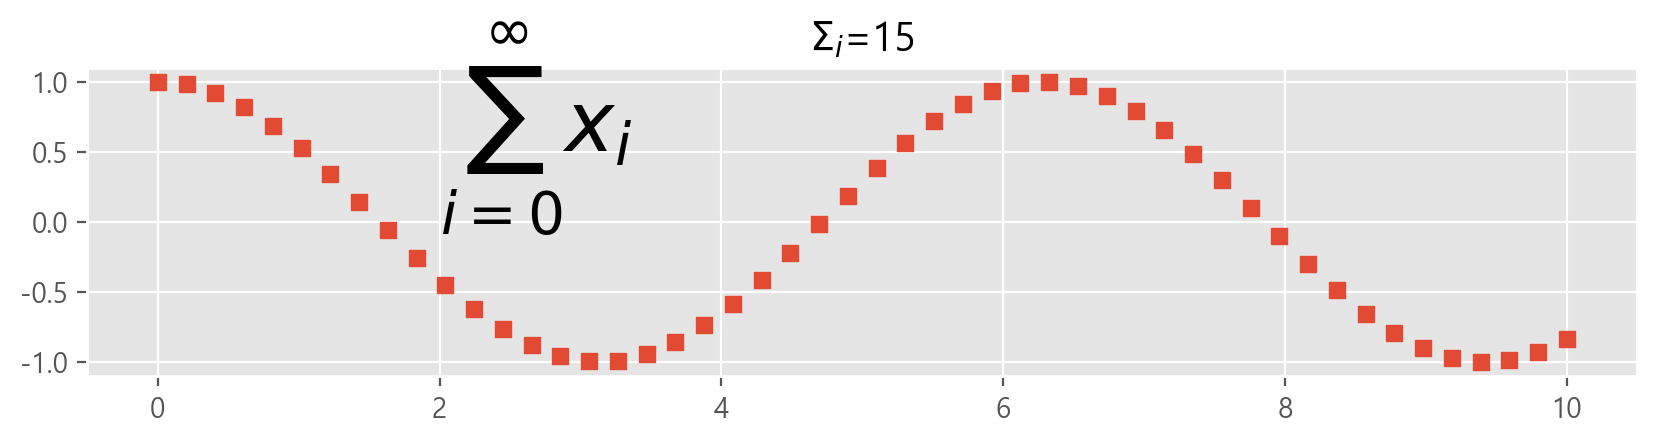

In [169]:

plt.scatter(x,y,marker='s')
plt.title(r'$\Sigma_i$=15')
plt.text(2,0.5,r'$\sum_{i=0}^\infty x_i$',fontsize=30)
plt.show()

### 4) 축과 눈금
- https://matplotlib.org/3.1.0/api/axis_api.html(교인 33p)

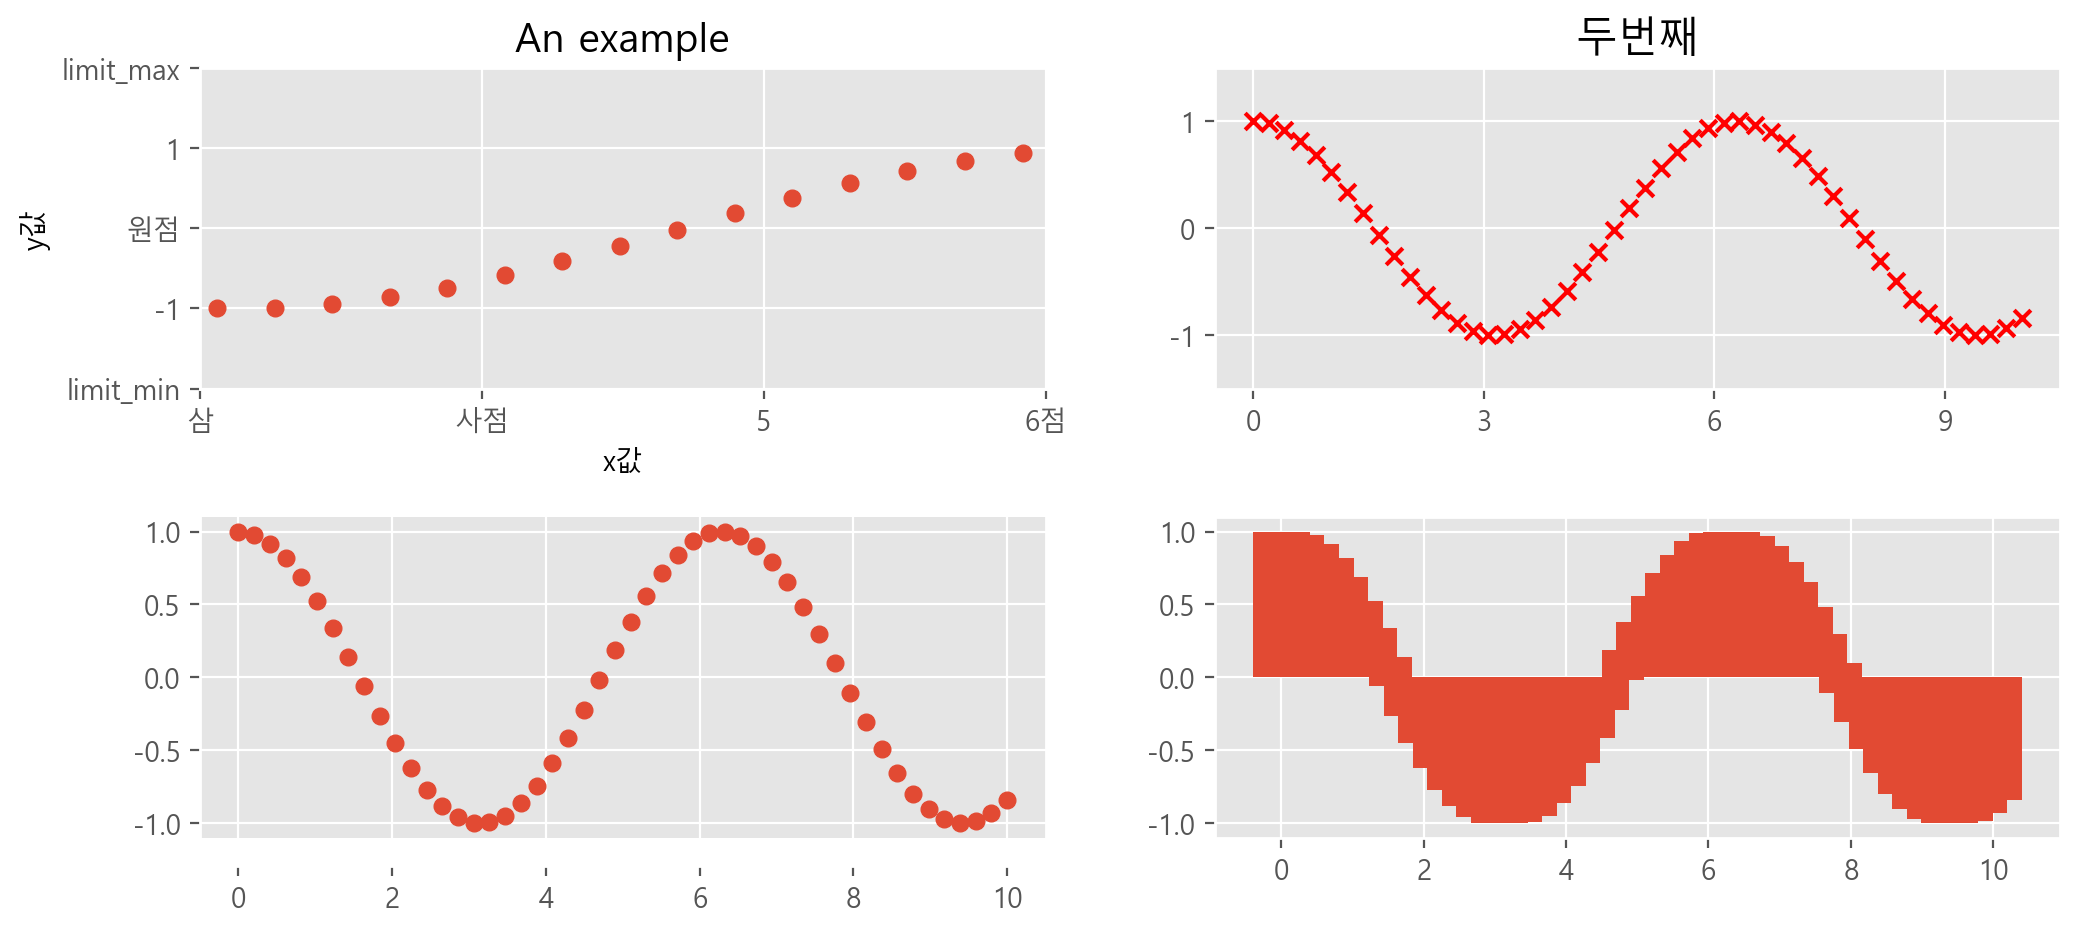

In [180]:
fig, axes = plt.subplots(2,2,figsize=(12,5))
#subplot끼리 여백조정
plt.subplots_adjust(hspace=0.4) # hspace위 아래 여백(1은 서브플롯세로높이)
axes[0,0].scatter(x,y)
axes[0,0].set(title='An example',
              ylabel='y값',
              xlabel='x값',
              ylim=[-2,2], # y축 눈금 범위
              xlim=[3,6],
              yticks=[-2,-1,0,1,2], #y축 눈금
              yticklabels=['limit_min',-1,'원점',1,'limit_max'],# y축 눈금의 라벨
              xticks=[3,4,5,6],
              xticklabels=['삼','사점',5,'6점'])
axes[0,1].scatter(x,y,c='r',marker='x')
axes[0,1].set_title('두번째',fontsize=15)
axes[0,1].set_xticks(range(0,11,3))
axes[0,1].set_ylim(-1.5,1.5)

axes[1,0].scatter(x,y)
axes[1,0].spines['top'].set_visible(False)
 #10pt만큼 바깥으로 이동
axes[1,0].spines['bottom'].set_position(('outward', 10))
axes[1,1].bar(x,y)
axes[1,1].grid(True)
plt.show()

### 5) ★축공유★

In [182]:
import numpy as np
x=np.arange(0,10)
y1=0.5*x**2
y2=-y1
print(x)
print(y1)
print(y2)

[0 1 2 3 4 5 6 7 8 9]
[ 0.   0.5  2.   4.5  8.  12.5 18.  24.5 32.  40.5]
[ -0.   -0.5  -2.   -4.5  -8.  -12.5 -18.  -24.5 -32.  -40.5]


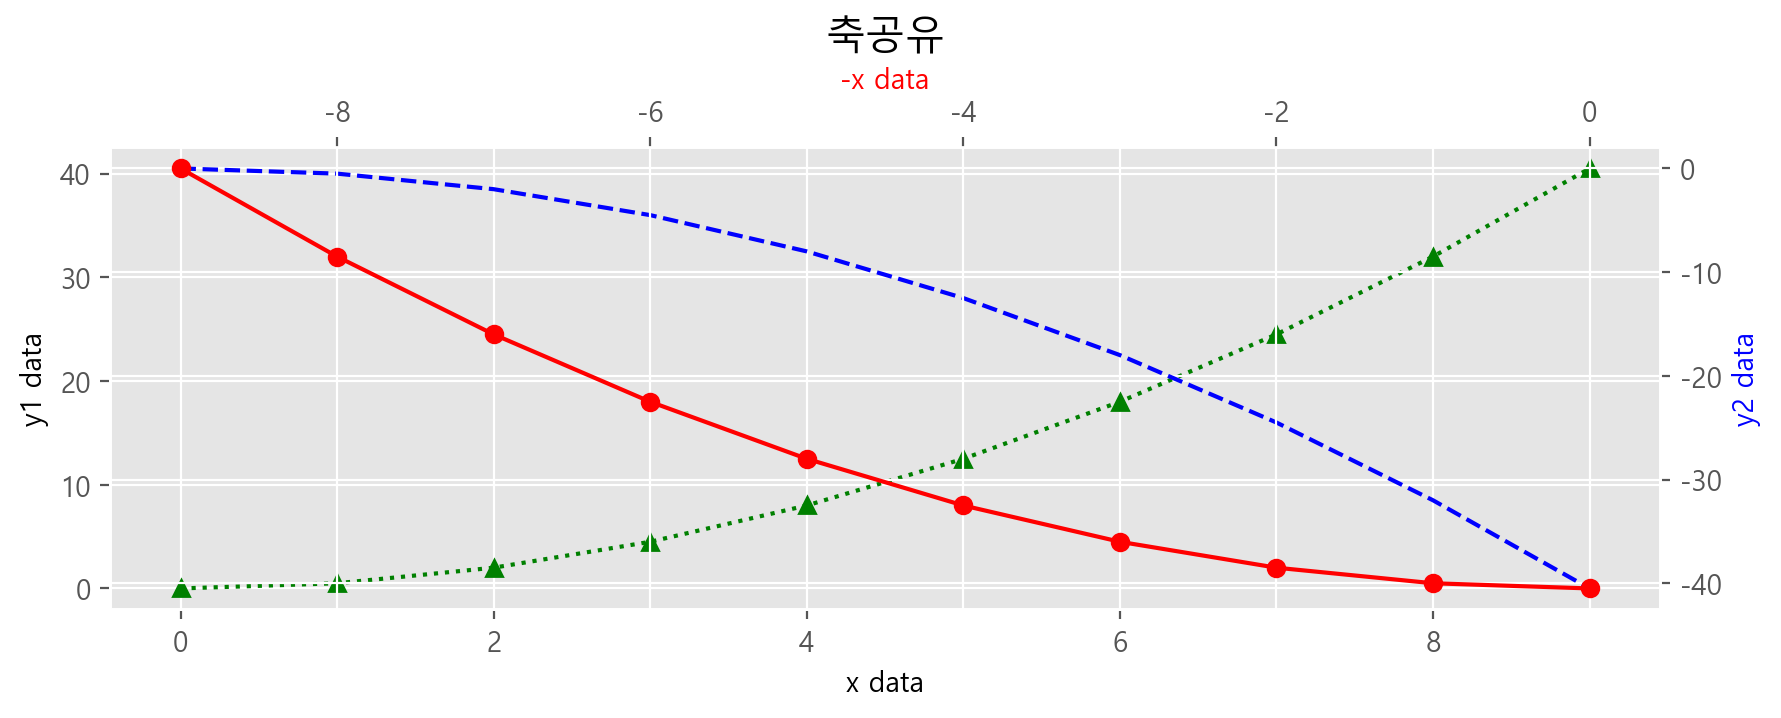

In [189]:
fig, ax1 = plt.subplots(figsize=(10,3))
ax1.plot(x,y1,'g^:')
ax1.set(title='축공유',xlabel='x data',ylabel='y1 data')

ax2=ax1.twinx() #ax1과 x축을 공유하는 ax2
ax2.plot(x,y2,'b--')
ax2.set_ylabel('y2 data',color='b')

ax3=ax1.twiny() #ax1과 y축을 공유하는 ax3
ax3.plot(-x,y1,'ro-')
ax3.set_xlabel('-x data',color='r')
plt.show()

###  6)범례표시
- https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot
### 7)플롯 스타일 지정
- 플롯 스타일 지정시 플롯의 기존 설정값이 초기화
    * plt.rc( 

In [191]:
plt.style.use('ggplot')
plt.rc('font',family='Malgun Gothic')
plt.rc('axes',unicode=minus=False)

SyntaxError: invalid syntax (324906795.py, line 3)

In [190]:
plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False